# Tutorial #1: Analysis of PCNs

We see how to analyse a PCN, studying its behaviour with respect to gradient updates.
The code is an adaptation from tutorial #0. In particular, the code defining the model is unchanged, and only the training functions are expanded to include the analysis part.

In [3]:
# Install dependencies not included in the base requirements.txt

# !pip install scikit-learn matplotlib

In [1]:
import numpy as np
from typing import Callable

import jax
import jax.tree_util as jtu
import jax.numpy as jnp
import equinox as eqx

import pcx as px
import pcx.predictive_coding as pxc
import pcx.nn as pxnn
import pcx.functional as pxf
import pcx.utils as pxu

from pcx.nn._layer import Linear, LayerParam
from pcx.core._random import RandomKeyGenerator, RKG

import optax

In [17]:
# class ScaledLinear(Linear):
#     """PC-optimized linear layer with symmetric initialization"""
#     def __init__(
#         self,
#         in_features: int,
#         out_features: int,
#         bias: bool = True,
#         *,
#         rkg: RandomKeyGenerator = None,
#         **kwargs
#     ):
#         # Initialize RKG if not provided
#         if rkg is None:
#             rkg = RandomKeyGenerator(seed=42)
        
#         # First create layer with default initialization
#         super().__init__(in_features, out_features, bias=bias, rkg=rkg, **kwargs)
        
#         # Now override parameters with scaled values
#         scale = 1.0 / jnp.sqrt(in_features + out_features)
#         key1, key2 = jax.random.split(rkg())
        
#         # Get existing parameter structure
#         new_nn = self.nn
        
#         # Replace weights
#         new_nn = eqx.tree_at(
#             lambda tree: tree.weight,
#             new_nn,
#             replace_fn=lambda w: LayerParam(scale * jax.random.normal(key1, w.shape))
#         )
        
#         # Replace biases if present
#         if new_nn.bias is not None:
#             new_nn = eqx.tree_at(
#                 lambda tree: tree.bias,
#                 new_nn,
#                 replace_fn=lambda b: LayerParam(0.1 * scale * jax.random.normal(key2, b.shape))
#             )
            
#         self.nn = new_nn
        

class ScaledLinear(pxnn.Linear):
    def __init__(self, in_features, out_features, *, rkg=None, use_bias=True, **kwargs):
        # Initialize parent without parameters
        super().__init__(in_features, out_features, bias=False)  # Disable parent bias
        
        # Initialize keys and parameters manually
        if rkg is None:
            rkg = RandomKeyGenerator(seed=42)
        key = rkg()
        key1, key2 = jax.random.split(key)
        
        # PC-specific scaling
        scale = 1.0 / jnp.sqrt(in_features + out_features)
        self.weight = pxnn.LayerParam(scale * jax.random.normal(key1, (out_features, in_features)))
        
        # Handle bias separately
        self.use_bias = use_bias
        if self.use_bias:
            self.bias = pxnn.LayerParam(scale * 0.1 * jax.random.normal(key2, (out_features,)))
        else:
            self.bias = None

    def __call__(self, x):
        x = jnp.dot(x, self.weight.get().T)
        if self.use_bias:
            x += self.bias.get()
        return x


class Model(pxc.EnergyModule):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        nm_layers: int,
        act_fn: Callable[[jax.Array], jax.Array]
    ) -> None:
        super().__init__()

        self.act_fn = px.static(act_fn)
        
        # Use ScaledLinear instead of default Linear
        # Share a single RKG instance across layers
        self.rkg = RandomKeyGenerator(seed=42)
        
        self.layers = [
            ScaledLinear(input_dim, hidden_dim, rkg=self.rkg),
            *[ScaledLinear(hidden_dim, hidden_dim, rkg=self.rkg) for _ in range(nm_layers-2)],
            ScaledLinear(hidden_dim, output_dim, rkg=self.rkg)
        ]

        self.vodes = [
            pxc.Vode() for _ in range(nm_layers - 1)
        ] + [pxc.Vode(pxc.ce_energy)]
        
        self.vodes[-1].h.frozen = True

    def __call__(self, x, y):
        activation_stats = []
        for i, (v, l) in enumerate(zip(self.vodes[:-1], self.layers[:-1])):
            x = l(x)
            pre_act = (jnp.mean(x), jnp.std(x))
            x = v(self.act_fn(x))
            post_act = jnp.mean(x)
            activation_stats.append((i, pre_act[0], pre_act[1], post_act))
        
        # Final layer handling
        x = self.layers[-1](x)
        activation_stats.append((-1, jnp.mean(x), jnp.std(x), 0.0))  # Use -1 instead of 'final'
        
        return x, activation_stats
    

@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0, 0), out_axes=0)
def forward(x, y, *, model: Model):
    return model(x, y)


@pxf.vmap(pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0)), in_axes=(0,), out_axes=(None, 0), axis_name="batch")
def energy(x, *, model: Model):
    y_ = model(x, None)
    return jax.lax.psum(model.energy(), "batch"), y_


@pxf.jit(static_argnums=0)
def train_on_batch(
    T: int,
    x: jax.Array,
    y: jax.Array,
    *,
    model: Model,
    optim_w: pxu.Optim,
    optim_h: pxu.Optim
):
    model.train()

    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)

    for i in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            (e, y_), g = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]),
                has_aux=True
            )(energy)(x, model=model)
        
        optim_h.step(model, g["model"])

    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, y_), g = pxf.value_and_grad(pxu.M(pxnn.LayerParam).to([False, True]), has_aux=True)(energy)(x, model=model)
    optim_w.step(model, g["model"], scale_by=1.0/x.shape[0])


@pxf.jit()
def eval_on_batch(x: jax.Array, y: jax.Array, *, model: Model):
    model.eval()
    
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        y_ = forward(x, None, model=model).argmax(axis=-1)
    
    return (y_ == y).mean(), y_


def train(dl, T, *, model: Model, optim_w: pxu.Optim, optim_h: pxu.Optim):
    for x, y in dl:
        train_on_batch(T, x, jax.nn.one_hot(y, 2), model=model, optim_w=optim_w, optim_h=optim_h)
        

def eval(dl, *, model: Model):
    acc = []
    ys_ = []
    
    for x, y in dl:
        a, y_ = eval_on_batch(x, y, model=model)
        acc.append(a)
        ys_.append(y_)
    
    return np.mean(acc), np.concatenate(ys_)


batch_size = 64
nm_layers = 4

# we merge initialisation in a single function to be able to create multiple models.
def init(
    batch_size: int,
    hidden_dim: int,
    h_lr: float = 1e-2,
    nm_layers: int = 4,
    act_fn: Callable[[jax.Array], jax.Array] = jax.nn.leaky_relu
):
    
    h_lr_base = h_lr  # User-provided base rate
    h_lr_actual = h_lr_base * jnp.sqrt(1 / hidden_dim)
    
    model = Model(
        input_dim=2,
        hidden_dim=hidden_dim,
        output_dim=2,
        nm_layers=nm_layers,
        act_fn=act_fn
    )
    
    # here, we use a state optimizer without internal state (i.e., no momentum), so we
    # initialise it once without the need to init/clear it for every batch.
    # we also perform a dummy forward pass so to initialise the `Vodes` before the first
    # `train_on_batch` call to avoid recompilation.
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(jax.numpy.zeros((batch_size, 2)), None, model=model)
        
        optim_h = pxu.Optim(lambda: optax.sgd(h_lr_actual), pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))
        optim_w = pxu.Optim(lambda: optax.adamw(1e-2), pxu.M(pxnn.LayerParam)(model))
    
    return model, optim_h, optim_w

In [18]:
from sklearn.datasets import make_moons

nm_elements = 512
X, y = make_moons(n_samples=batch_size * (nm_elements // batch_size), noise=0.2, random_state=42)

train_dl = list(zip(X.reshape(-1, batch_size, 2), y.reshape(-1, batch_size)))

X_test, y_test = make_moons(n_samples=batch_size * (nm_elements // batch_size) // 2, noise=0.2, random_state=0)
test_dl = tuple(zip(X_test.reshape(-1, batch_size, 2), y_test.reshape(-1, batch_size)))

### Analysis

Instead of training a single PCN, we iterate over several hidden widths and for each resulting network we compute the best h learning rate.
Note that we do not change the number of layers (set to 4) or the number of inference steps (set to 8).

Ideally hidden width and h learning rate should be independent values, as the h learning rate should only affect how the error propagates through multiple layers, and be uneffected by the properties of each single layer (also because this would make networks with layers of different sizes inheritely difficult to train).

In [24]:
def init(
    batch_size: int,
    hidden_dim: int,
    h_lr: float = 1e-2,
    nm_layers: int = 4,
    act_fn: Callable[[jax.Array], jax.Array] = jax.nn.leaky_relu
):
    model = Model(
        input_dim=2,
        hidden_dim=hidden_dim,
        output_dim=2,
        nm_layers=nm_layers,
        act_fn=act_fn
    )
    
    # Use a single key for initialization instead of batch-wise keys
    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        # Single sample initialization
        forward(jax.numpy.zeros((1, 2)), None, model=model)  # Changed from batch_size to 1
        
        # Adaptive learning rate
        h_lr_actual = h_lr * jnp.sqrt(1 / hidden_dim)
        optim_h = pxu.Optim(lambda: optax.sgd(h_lr_actual), 
                          pxu.M_hasnot(pxc.VodeParam, frozen=True)(model))
        optim_w = pxu.Optim(lambda: optax.adamw(1e-2), 
                          pxu.M(pxnn.LayerParam)(model))
    
    return model, optim_h, optim_w


# Test initialization
model, _, _ = init(batch_size=64, hidden_dim=32, h_lr=1e-3)

# Check layer structure
layer = model.layers[0]
print("Weight shape:", layer.weight.get().shape)  # Should be (32, 2)
print("Bias present:", layer.use_bias)  # Should be True
print("Bias shape:", layer.bias.get().shape if layer.use_bias else None)

# Verify parameter scaling
expected_scale = 1/jnp.sqrt(2 + 32)
actual_std = jnp.std(layer.nn.weight.get())
print(f"\nScale check (10% tolerance): {jnp.isclose(actual_std, expected_scale, rtol=0.1)}")





Weight shape: (32, 2)
Bias present: True
Bias shape: (32,)

Scale check (10% tolerance): False


In [19]:
test_key = jax.random.PRNGKey(42)
print(test_key)  # Should be Array([0, 0], dtype=uint32)
key1, key2 = jax.random.split(test_key)
print(key1, key2)  # Should show 2 distinct keys


[ 0 42]
[2465931498 3679230171] [255383827 267815257]


In [4]:
import random

nm_epochs = 32 // (nm_elements // batch_size)

# We test over the following values
h_dims = [16, 32, 64, 128, 256, 512, 1024, 2048]
h_lrs = [1e-3, 3e-3, 5e-3, 1e-2, 3e-2, 5e-2, 1e-1, 3e-1, 5e-1]

h_dims = [16, 32]
h_lrs = [1e-3, 3e-3]

def run(
    nm_epochs,
    model,
    optim_h,
    optim_w,
    train_dl,
    test_dl,
    T = 8
):
    for _ in range(nm_epochs):
        random.shuffle(train_dl)
        train(train_dl, T=T, model=model, optim_w=optim_w, optim_h=optim_h)
    a, _ = eval(test_dl, model=model)
    
    return a


acc_by_dim = {}

for h_dim in h_dims:
    acc_by_dim[h_dim] = []
    for h_lr in h_lrs:
        print(f"Running h_dim={h_dim} and h_lr={h_lr}.", end=" ")
        model, optim_h, optim_w = init(batch_size, h_dim, h_lr, act_fn=jax.nn.selu)
        a = run(nm_epochs, model, optim_h, optim_w, train_dl, test_dl, 8)
        acc_by_dim[h_dim].append(a)
        print(f"Accuracy: {(a*100.0):.2f}%")

Running h_dim=16 and h_lr=0.001. 

TypeError: Output from batched function 'final' with type <class 'str'> is not a valid JAX type

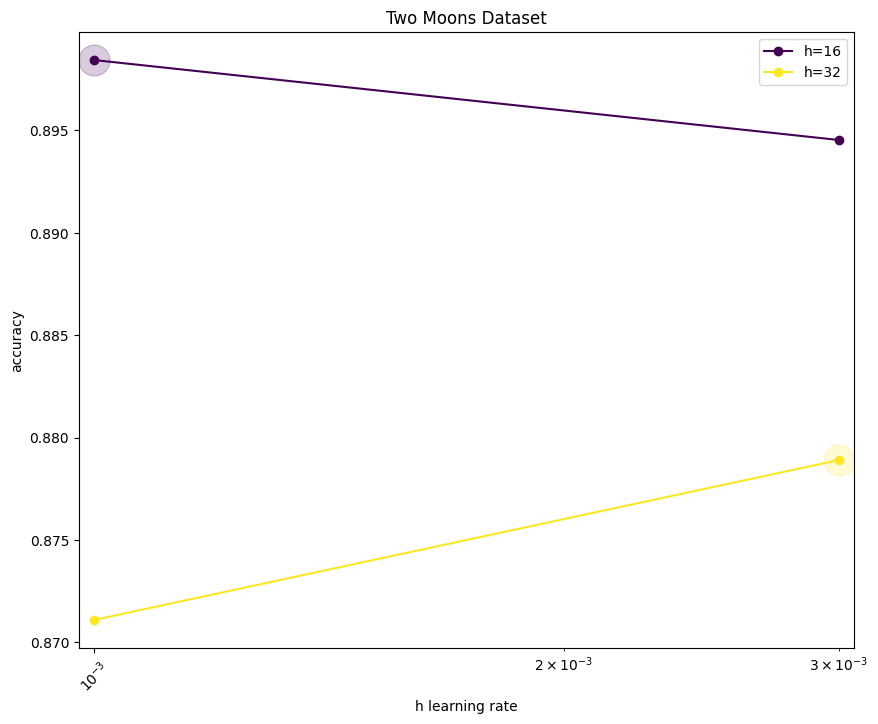

In [17]:
import matplotlib.pyplot as plt


# Plot the dataset
plt.figure(figsize=(10, 8))

for i, (h_dim, accs) in enumerate(acc_by_dim.items()):
    color = plt.get_cmap('viridis')(i / (len(acc_by_dim) - 1))
    plt.plot(h_lrs, accs, marker="o", color=color, label=f"h={h_dim}")
    
    max_acc = max(accs)
    i_max = accs.index(max_acc)
    plt.scatter(h_lrs[i_max], max_acc, s=500, color=color, alpha=0.2)

plt.margins(x = 0.02)
plt.xticks(h_lrs, h_lrs, rotation=45)
plt.xscale("log")
plt.legend()
plt.title("Two Moons Dataset")
plt.xlabel("h learning rate")
plt.ylabel("accuracy")
plt.show()

We can see that our hypothesis is wrong! And the best learning rate changes drastically for different hidden sizes. This is true for different choices of activation function, and even by using a SE energy instead of the standard CE energy (so it is unrelated to it, note that SE energy performs drastically worse than CE, as expected). We chose to use leaky_relu as default activation function to show the most evident correlation (note that based on the seed it not be perfect).

What we see is that high hidden dim values prefer small learning rates and are unstable for larger values. This does not apply to BP, which is unaffected by the width of the network. Something is wrong, could it be the default weight initialisation being not suitable for PC (to this day, we haven't solved this, but we are working on it)?

In "Understanding the difficulty of training deep feedforward neural networks", the authors suggest that the variance of the gradients should be costant through the network, as we want information that doesn't vanish or explode throughout the layers (eqs. 8,9, 14). To measure this, we check the ratio between the gradients of different layers. To do so, we modify the train function to return such information:

In [23]:
@pxf.jit(static_argnums=0)
def train_on_batch_with_ratio(
    T: int,
    x: jax.Array,
    y: jax.Array,
    *,
    model: Model,
    optim_w: pxu.Optim,
    optim_h: pxu.Optim
):
    model.train()

    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)

    for i in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            (e, y_), g = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]),
                has_aux=True
            )(energy)(x, model=model)
        
        optim_h.step(model, g["model"])

    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, y_), g = pxf.value_and_grad(pxu.M(pxnn.LayerParam).to([False, True]), has_aux=True)(energy)(x, model=model)
    optim_w.step(model, g["model"], scale_by=1.0/x.shape[0])
    
    # We measure the variance of the gradients for the second and third layer
    # Note that by having 4 layers in total we guaranteed that the two layers we compare have the same shape.
    assert g["model"].layers[1].nn.weight.get().shape == g["model"].layers[2].nn.weight.get().shape, "Shapes can't be different"
    var_g_w1 = jnp.var(g["model"].layers[1].nn.weight.get())
    var_g_w2 = jnp.var(g["model"].layers[2].nn.weight.get())
    
    return var_g_w1 / var_g_w2


def train_with_ratio(dl, T, *, model: Model, optim_w: pxu.Optim, optim_h: pxu.Optim):
    ratios = []
    for x, y in dl:
        ratio = train_on_batch_with_ratio(T, x, jax.nn.one_hot(y, 2), model=model, optim_w=optim_w, optim_h=optim_h)
        ratios.append(ratio)
        
    return np.mean(ratios)

def run_with_ratio(
    nm_epochs,
    model,
    optim_h,
    optim_w,
    train_dl,
    test_dl,
    T = 16
):
    for i in range(nm_epochs):
        random.shuffle(train_dl)
        ratio = train_with_ratio(train_dl, T=T, model=model, optim_w=optim_w, optim_h=optim_h)
        print(f"\tAvg. gradient ratio for epoch {i + 1}: {ratio}")
    a, _ = eval(test_dl, model=model)
    
    return a

In [24]:
h_dims = [50, 200, 800, 1600]
# we use a learning rate that works for all the chosen dims.
h_lr = 3e-3

for h_dim in h_dims:
    print(f"Running h_dim={h_dim}")
    model, optim_h, optim_w = init(batch_size, h_dim, h_lr, act_fn=jax.nn.selu)
    a = run_with_ratio(nm_epochs, model, optim_h, optim_w, train_dl, test_dl, 16)
    print(f"Accuracy: {(a*100.0):.2f}%")

Running h_dim=50
	Avg. gradient ratio for epoch 1: 3.6344205000204965e-05
	Avg. gradient ratio for epoch 2: 4.404395804158412e-05
	Avg. gradient ratio for epoch 3: 4.606692891684361e-05
	Avg. gradient ratio for epoch 4: 5.54343314433936e-05
Accuracy: 89.06%
Running h_dim=200
	Avg. gradient ratio for epoch 1: 4.952967174176592e-06
	Avg. gradient ratio for epoch 2: 3.0276075904112076e-06
	Avg. gradient ratio for epoch 3: 1.7361876416543964e-06
	Avg. gradient ratio for epoch 4: 6.310900516837137e-06
Accuracy: 89.06%
Running h_dim=800
	Avg. gradient ratio for epoch 1: 8.952549251262099e-06
	Avg. gradient ratio for epoch 2: 1.7113949297709041e-06
	Avg. gradient ratio for epoch 3: 6.841941058155498e-07
	Avg. gradient ratio for epoch 4: 3.3901699225680204e-07
Accuracy: 85.55%
Running h_dim=1600
	Avg. gradient ratio for epoch 1: 1.4850744264549576e-05
	Avg. gradient ratio for epoch 2: 6.104242856963538e-06
	Avg. gradient ratio for epoch 3: 3.5209998259233544e-06
	Avg. gradient ratio for epoch 

In [13]:
h_dims = [50, 200, 800, 1600]
# we use a learning rate that works for all the chosen dims.
h_lr = 3e-3

for h_dim in h_dims:
    print(f"Running h_dim={h_dim}")
    model, optim_h, optim_w = init(batch_size, h_dim, h_lr, act_fn=jax.nn.leaky_relu)
    a = run_with_ratio(nm_epochs, model, optim_h, optim_w, train_dl, test_dl, 16)
    print(f"Accuracy: {(a*100.0):.2f}%")

Running h_dim=50
	Avg. gradient ratio for epoch 1: 1.2657648767344654e-05
	Avg. gradient ratio for epoch 2: 1.7676724382909015e-05
	Avg. gradient ratio for epoch 3: 1.713507663225755e-05
	Avg. gradient ratio for epoch 4: 1.3800233318761457e-05
Accuracy: 90.23%
Running h_dim=200
	Avg. gradient ratio for epoch 1: 1.1465251645859098e-06
	Avg. gradient ratio for epoch 2: 4.3619959910756734e-07
	Avg. gradient ratio for epoch 3: 2.980084900627844e-06
	Avg. gradient ratio for epoch 4: 8.610605846115504e-07
Accuracy: 83.59%
Running h_dim=800
	Avg. gradient ratio for epoch 1: 4.1425226982028107e-07
	Avg. gradient ratio for epoch 2: 3.525420311234484e-07
	Avg. gradient ratio for epoch 3: 7.304754490178311e-08
	Avg. gradient ratio for epoch 4: 3.8422288639594626e-07
Accuracy: 85.55%
Running h_dim=1600
	Avg. gradient ratio for epoch 1: 6.368608183038305e-07
	Avg. gradient ratio for epoch 2: 1.0383116944012727e-07
	Avg. gradient ratio for epoch 3: 1.014698938206493e-07
	Avg. gradient ratio for epoc

We can see that the ratio is not stable, as it should instead be. Note that by increasing the h learning rate or the number T of inference steps, it can be brought closer to 1 for the smaller architectures. However, larger h learning rates make big architectures unstable, making the difficult to train (as you can only play around with T and increase the total computational cost).

### My code


=== Testing SILU ===
Running silu with h_dim=16 and h_lr=1e-03 → Accuracy: 90.23%
Running silu with h_dim=16 and h_lr=3e-03 → Accuracy: 88.67%
Running silu with h_dim=16 and h_lr=5e-03 → Accuracy: 87.11%
Running silu with h_dim=16 and h_lr=1e-02 → Accuracy: 94.53%
Running silu with h_dim=16 and h_lr=3e-02 → Accuracy: 93.36%
Running silu with h_dim=16 and h_lr=5e-02 → Accuracy: 95.70%
Running silu with h_dim=16 and h_lr=1e-01 → Accuracy: 94.14%
Running silu with h_dim=16 and h_lr=3e-01 → Accuracy: 93.36%
Running silu with h_dim=16 and h_lr=5e-01 → Accuracy: 93.75%
Running silu with h_dim=256 and h_lr=1e-03 → Accuracy: 89.84%
Running silu with h_dim=256 and h_lr=3e-03 → Accuracy: 88.67%
Running silu with h_dim=256 and h_lr=5e-03 → Accuracy: 89.06%
Running silu with h_dim=256 and h_lr=1e-02 → Accuracy: 89.06%
Running silu with h_dim=256 and h_lr=3e-02 → Accuracy: 90.62%
Running silu with h_dim=256 and h_lr=5e-02 → Accuracy: 91.41%
Running silu with h_dim=256 and h_lr=1e-01 → Accuracy: 88

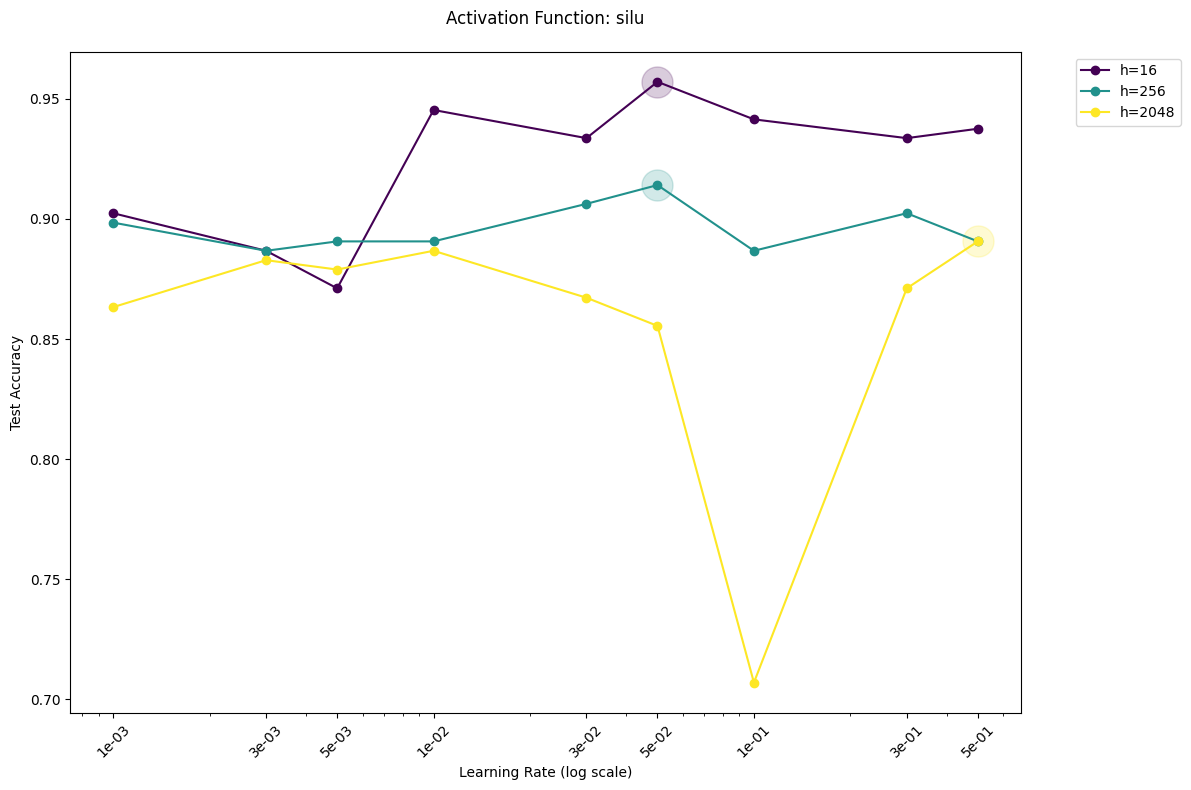

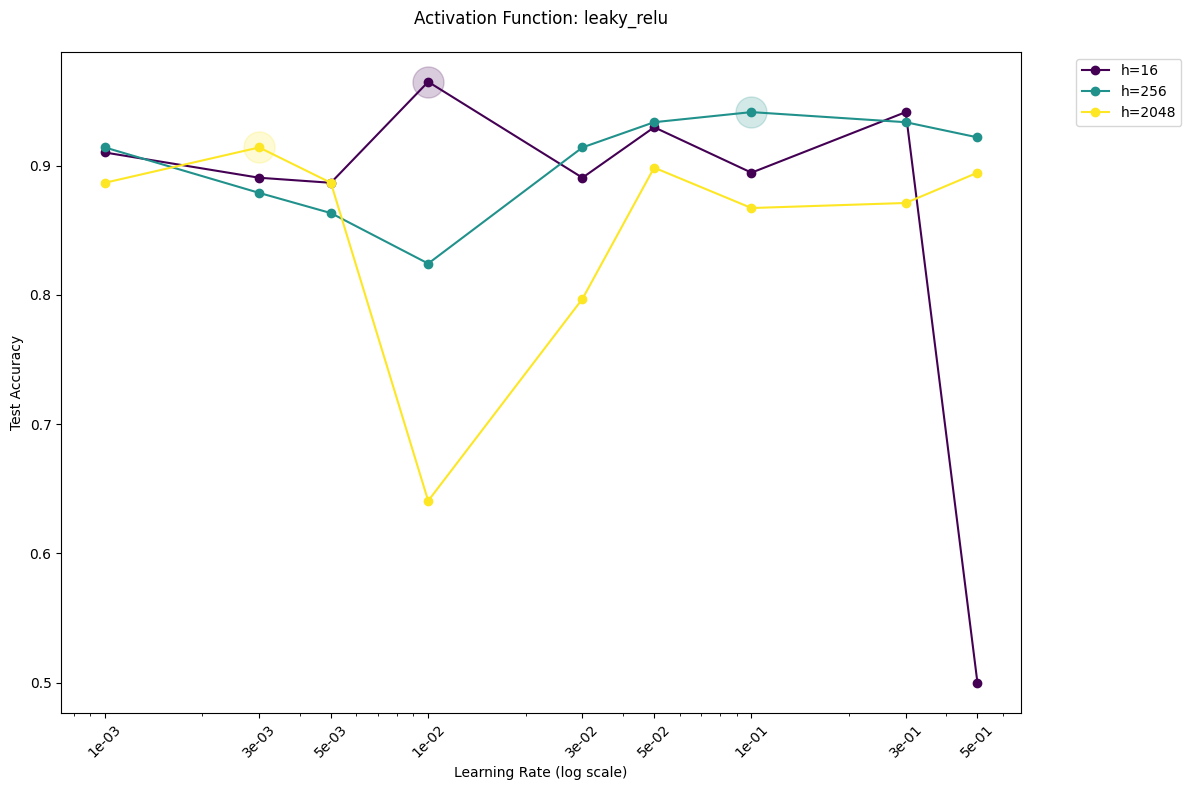

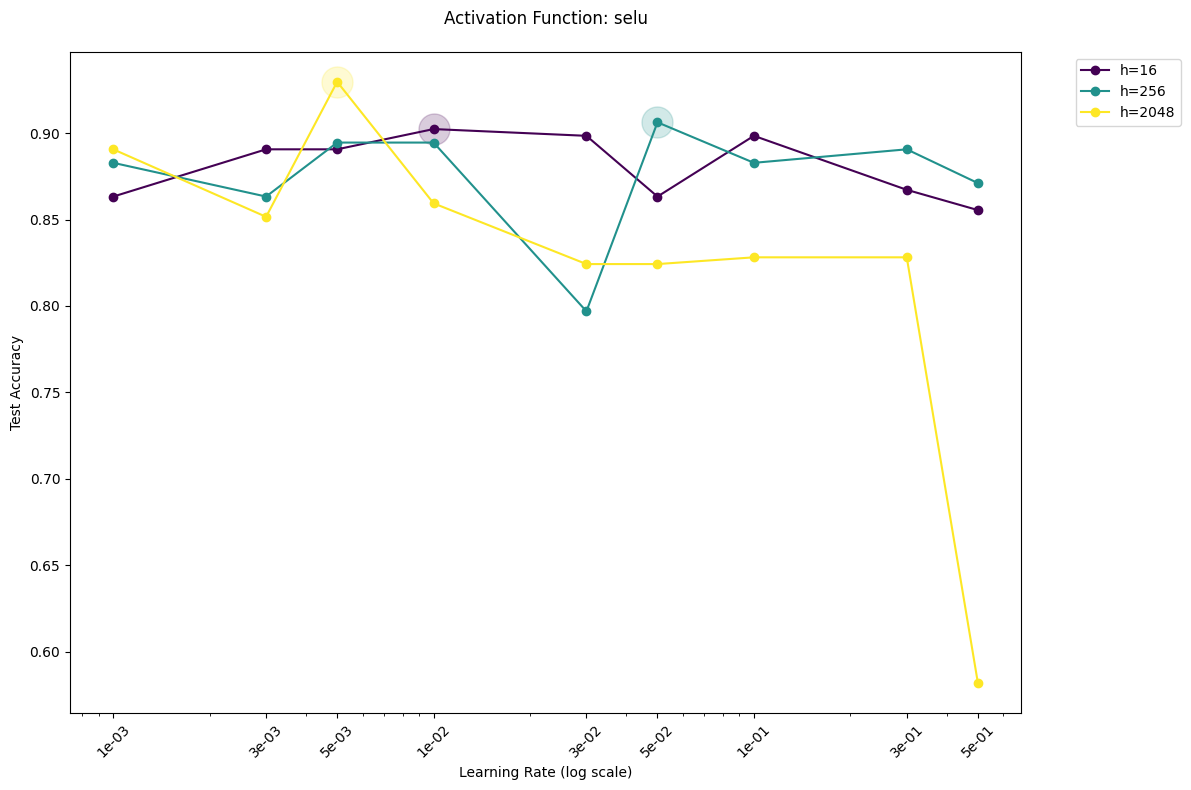

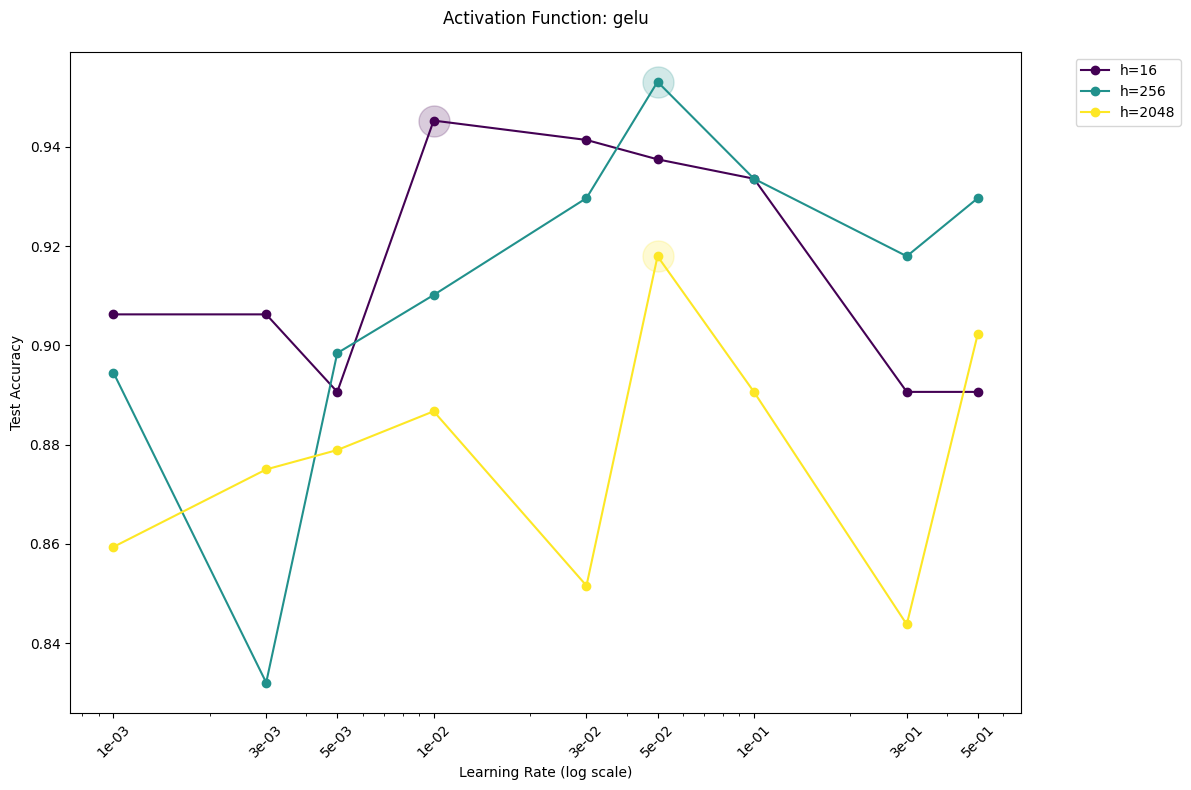

In [46]:
import random

nm_epochs = 64 // (nm_elements // batch_size)

# We test over the following values
h_dims = [16, 32, 64, 128, 256, 512, 1024, 2048]
h_lrs = [1e-3, 3e-3, 5e-3, 1e-2, 3e-2, 5e-2, 1e-1, 3e-1, 5e-1]

h_dims = [16, 256, 2048]
# h_lrs = [1e-3, 3e-2, 5e-1]

# h_dims = [16, 256]
# h_lrs = [1e-3, 3e-2, 5e-1]

def run(
    nm_epochs,
    model,
    optim_h,
    optim_w,
    train_dl,
    test_dl,
    T = 1
):
    for _ in range(nm_epochs):
        random.shuffle(train_dl)
        train(train_dl, T=T, model=model, optim_w=optim_w, optim_h=optim_h)
    a, _ = eval(test_dl, model=model)
    
    return a

# Define all activation functions to test
activation_fns = [
    # ('relu', jax.nn.relu),
    # ('relu6', jax.nn.relu6),
    # ('sigmoid', jax.nn.sigmoid),
    # ('softplus', jax.nn.softplus),
    # ('soft_sign', jax.nn.soft_sign),
    ('silu', jax.nn.silu),
    # ('swish', jax.nn.swish),
    # ('log_sigmoid', jax.nn.log_sigmoid),
    ('leaky_relu', jax.nn.leaky_relu),
    # ('hard_sigmoid', jax.nn.hard_sigmoid),
    # ('hard_silu', jax.nn.hard_silu),
    # ('hard_swish', jax.nn.hard_swish),
    # ('hard_tanh', jax.nn.hard_tanh),
    # ('elu', jax.nn.elu),
    # ('celu', jax.nn.celu),
    ('selu', jax.nn.selu),
    ('gelu', jax.nn.gelu),
    # ('glu', jax.nn.glu),
    # ('mish', jax.nn.mish),
]

acc_results = {}

for act_name, act_fn in activation_fns:
    print(f"\n=== Testing {act_name.upper()} ===")
    acc_results[act_name] = {}
    
    for h_dim in h_dims:
        acc_results[act_name][h_dim] = []
        for h_lr in h_lrs:
            print(f"Running {act_name} with h_dim={h_dim} and h_lr={h_lr:.0e}", end=" ")
            model, optim_h, optim_w = init(batch_size, h_dim, h_lr, act_fn=act_fn)
            a = run(nm_epochs, model, optim_h, optim_w, train_dl, test_dl, 8)
            acc_results[act_name][h_dim].append(a)
            print(f"→ Accuracy: {(a*100.0):.2f}%")

# Plot results for each activation function
for act_name in acc_results:
    plt.figure(figsize=(12, 8))
    acc_by_dim = acc_results[act_name]
    
    for i, (h_dim, accs) in enumerate(acc_by_dim.items()):
        color = plt.get_cmap('viridis')(i / (len(acc_by_dim) - 1))
        plt.plot(h_lrs, accs, marker="o", color=color, label=f"h={h_dim}")
        
        max_acc = max(accs)
        i_max = accs.index(max_acc)
        plt.scatter(h_lrs[i_max], max_acc, s=500, color=color, alpha=0.2)
    
    plt.title(f"Activation Function: {act_name}", pad=20)
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Test Accuracy")
    plt.xscale("log")
    plt.xticks(h_lrs, [f"{lr:.0e}" for lr in h_lrs], rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



=== Testing h_dim=16 ===

=== Testing h_dim=256 ===

=== Testing h_dim=2024 ===


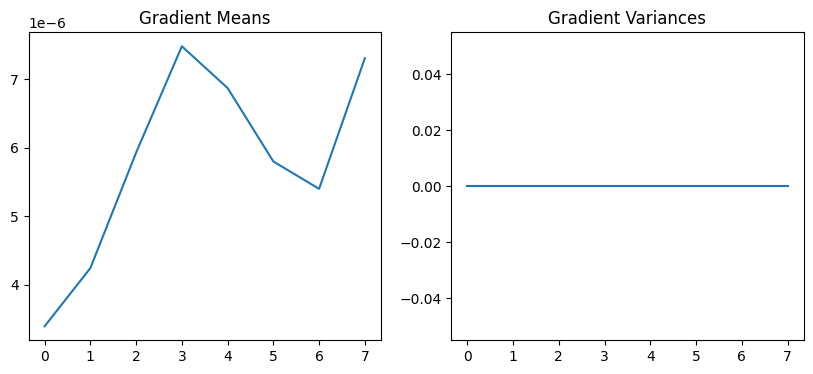

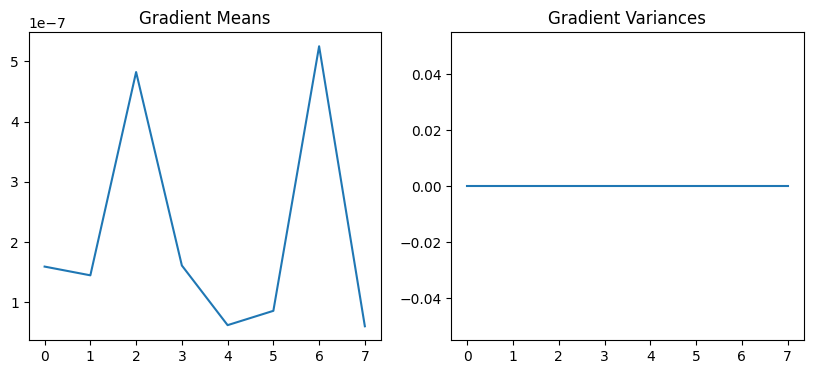

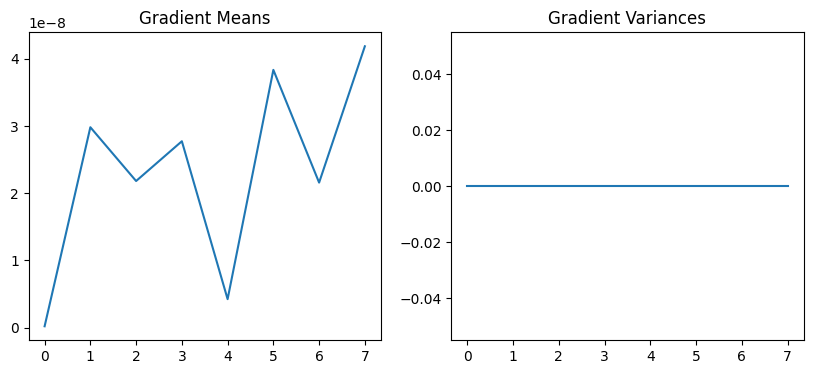

In [49]:
import matplotlib.pyplot as plt

# Gradient statistics monitor
def plot_grad_stats(metrics):
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.plot([m['grad_mean'] for m in metrics])
    plt.title("Gradient Means")
    
    plt.subplot(122)
    plt.plot([m['grad_var'] for m in metrics])
    plt.title("Gradient Variances")
    
# Weight condition number tracking
def get_condition_numbers(model):
    return [jnp.linalg.cond(l.nn.weight.get()) for l in model.layers]


def train(dl, T, *, model: Model, optim_w: pxu.Optim, optim_h: pxu.Optim):
    metrics = []  # Initialize metrics collection
    for x, y in dl:
        ratio = train_on_batch_with_ratio(T, x, jax.nn.one_hot(y, 2), 
                                         model=model, optim_w=optim_w, optim_h=optim_h)
        metrics.append({
            'grad_mean': jnp.mean(ratio),
            'grad_var': jnp.var(ratio)
        })
    return metrics  # Return collected metrics


# Comparison experiment template
for h_dim in [16, 256, 2024]:
    print(f"\n=== Testing h_dim={h_dim} ===")
    model, optim_h, optim_w = init(batch_size, h_dim, h_lr=3e-3)
    metrics = train(
        train_dl,  # Add data loader
        T=8,       # Add inference steps (matches your earlier setup) 
        model=model,
        optim_w=optim_w,
        optim_h=optim_h
    )
    plot_grad_stats(metrics)

In [62]:
nm_epochs = 64 // (nm_elements // batch_size)

# We test over the following values
# h_dims = [16, 32, 64, 128, 256, 512, 1024, 2048]
# h_lrs = [1e-3, 3e-3, 5e-3, 1e-2, 3e-2, 5e-2, 1e-1, 3e-1, 5e-1]

# h_dims = [16, 256, 2048]
# h_lrs = [1e-3, 3e-2, 5e-1]

h_dims = [16, 32]
h_lrs = [1e-3, 3e-2]

def run(
    nm_epochs,
    model,
    optim_h,
    optim_w,
    train_dl,
    test_dl,
    T = 1
):
    for _ in range(nm_epochs):
        random.shuffle(train_dl)
        train(train_dl, T=T, model=model, optim_w=optim_w, optim_h=optim_h)
    a, _ = eval(test_dl, model=model)
    
    return a

# Define all activation functions to test
activation_fns = [
    # ('relu', jax.nn.relu),
    # ('relu6', jax.nn.relu6),
    # ('sigmoid', jax.nn.sigmoid),
    # ('softplus', jax.nn.softplus),
    # ('soft_sign', jax.nn.soft_sign),
    ('silu', jax.nn.silu),
    # ('swish', jax.nn.swish),
    # ('log_sigmoid', jax.nn.log_sigmoid),
    # ('leaky_relu', jax.nn.leaky_relu),
    # ('hard_sigmoid', jax.nn.hard_sigmoid),
    # ('hard_silu', jax.nn.hard_silu),
    # ('hard_swish', jax.nn.hard_swish),
    # ('hard_tanh', jax.nn.hard_tanh),
    # ('elu', jax.nn.elu),
    # ('celu', jax.nn.celu),
    ('selu', jax.nn.selu),
    # ('gelu', jax.nn.gelu),
    # ('glu', jax.nn.glu),
    # ('mish', jax.nn.mish),
]


In [63]:
%matplotlib inline
import matplotlib.pyplot as plt


In [64]:
@pxf.jit(static_argnums=0)
def train_on_batch_with_ratio(
    T: int,
    x: jax.Array,
    y: jax.Array,
    *,
    model: Model,
    optim_w: pxu.Optim,
    optim_h: pxu.Optim
):
    model.train()

    with pxu.step(model, pxc.STATUS.INIT, clear_params=pxc.VodeParam.Cache):
        forward(x, y, model=model)

    for i in range(T):
        with pxu.step(model, clear_params=pxc.VodeParam.Cache):
            (e, y_), g = pxf.value_and_grad(
                pxu.M_hasnot(pxc.VodeParam, frozen=True).to([False, True]),
                has_aux=True
            )(energy)(x, model=model)
        
        optim_h.step(model, g["model"])

    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        (e, y_), g = pxf.value_and_grad(pxu.M(pxnn.LayerParam).to([False, True]), has_aux=True)(energy)(x, model=model)
    optim_w.step(model, g["model"], scale_by=1.0/x.shape[0])
    
    # Gradient statistics for deeper analysis
    assert g["model"].layers[1].nn.weight.get().shape == g["model"].layers[2].nn.weight.get().shape
    
    # Get actual gradient values (not parameters)
    grad_w1 = g["model"].layers[1].nn.weight.get()
    grad_w2 = g["model"].layers[2].nn.weight.get()
    
    return {
        'ratio': jnp.var(grad_w1) / jnp.var(grad_w2),
        'mean_layer1': jnp.mean(grad_w1),
        'var_layer1': jnp.var(grad_w1),
        'mean_layer2': jnp.mean(grad_w2),
        'var_layer2': jnp.var(grad_w2)
    }

def train_with_ratio(dl, T, *, model: Model, optim_w: pxu.Optim, optim_h: pxu.Optim):
    metrics = []
    for x, y in dl:
        batch_metrics = train_on_batch_with_ratio(T, x, jax.nn.one_hot(y, 2), 
                                                 model=model, optim_w=optim_w, optim_h=optim_h)
        metrics.append(batch_metrics)
    return metrics

def run_with_ratio(
    nm_epochs,
    model,
    optim_h,
    optim_w,
    train_dl,
    test_dl,
    T = 16
):
    epoch_metrics = []
    for i in range(nm_epochs):
        random.shuffle(train_dl)
        batch_metrics = train_with_ratio(train_dl, T=T, model=model, optim_w=optim_w, optim_h=optim_h)
        
        # Aggregate epoch metrics
        epoch_avg = {
            'ratio': np.mean([m['ratio'] for m in batch_metrics]),
            'mean_l1': np.mean([m['mean_layer1'] for m in batch_metrics]),
            'var_l1': np.mean([m['var_layer1'] for m in batch_metrics]),
            'mean_l2': np.mean([m['mean_layer2'] for m in batch_metrics]),
            'var_l2': np.mean([m['var_layer2'] for m in batch_metrics])
        }
        epoch_metrics.append(epoch_avg)
        
        print(f"\nEpoch {i+1}:")
        print(f"  Gradient Ratio: {epoch_avg['ratio']:.2f}")
        print(f"  Layer1 - μ: {epoch_avg['mean_l1']:.2e}, σ²: {epoch_avg['var_l1']:.2e}")
        print(f"  Layer2 - μ: {epoch_avg['mean_l2']:.2e}, σ²: {epoch_avg['var_l2']:.2e}")
    
    a, _ = eval(test_dl, model=model)
    return a, epoch_metrics



=== Testing h_dim=16 ===

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: -5.20e-16, σ²: 1.06e-13
  Layer2 - μ: 9.45e-13, σ²: 4.33e-08

Epoch 2:
  Gradient Ratio: 0.00
  Layer1 - μ: 7.31e-16, σ²: 3.37e-14
  Layer2 - μ: 6.57e-14, σ²: 5.16e-09

Epoch 3:
  Gradient Ratio: 0.00
  Layer1 - μ: 5.19e-16, σ²: 4.78e-14
  Layer2 - μ: 3.31e-13, σ²: 6.14e-09

Epoch 4:
  Gradient Ratio: 0.00
  Layer1 - μ: -2.36e-15, σ²: 5.57e-14
  Layer2 - μ: -5.67e-13, σ²: 7.83e-09

Epoch 5:
  Gradient Ratio: 0.00
  Layer1 - μ: 2.34e-17, σ²: 2.96e-14
  Layer2 - μ: -4.49e-13, σ²: 4.52e-09

Epoch 6:
  Gradient Ratio: 0.00
  Layer1 - μ: 1.33e-15, σ²: 4.36e-14
  Layer2 - μ: 3.47e-13, σ²: 6.88e-09

Epoch 7:
  Gradient Ratio: 0.00
  Layer1 - μ: 8.38e-16, σ²: 4.70e-14
  Layer2 - μ: 2.32e-13, σ²: 8.09e-09

Epoch 8:
  Gradient Ratio: 0.00
  Layer1 - μ: 4.40e-16, σ²: 4.89e-14
  Layer2 - μ: -1.23e-13, σ²: 8.52e-09

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: -6.82e-15, σ²: 1.16e-11
  Layer2 - μ: -2.76e-12, σ²: 4.61e-07

Epo

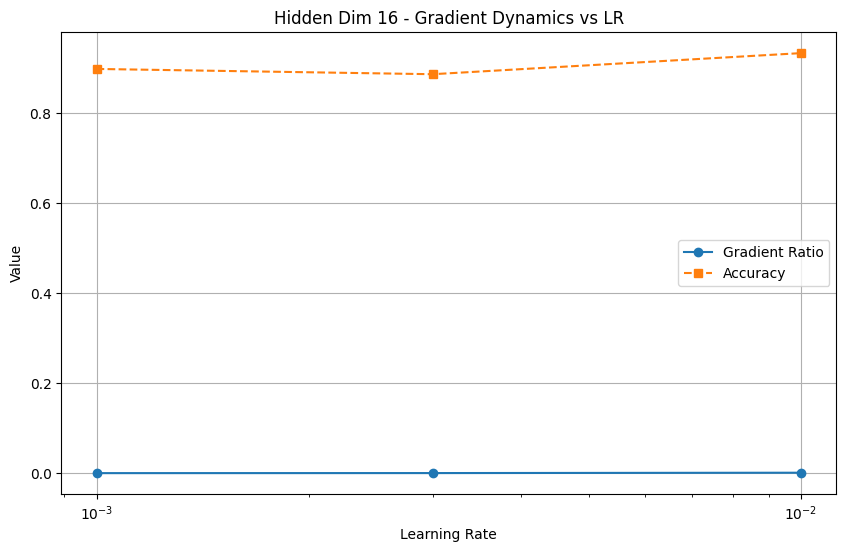


=== Testing h_dim=256 ===

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: 2.17e-18, σ²: 1.91e-18
  Layer2 - μ: 1.94e-15, σ²: 8.13e-11

Epoch 2:
  Gradient Ratio: 0.00
  Layer1 - μ: -1.36e-19, σ²: 3.29e-20
  Layer2 - μ: 2.78e-16, σ²: 1.12e-12

Epoch 3:
  Gradient Ratio: 0.00
  Layer1 - μ: 2.34e-19, σ²: 6.34e-20
  Layer2 - μ: -2.92e-16, σ²: 4.78e-13

Epoch 4:
  Gradient Ratio: 0.00
  Layer1 - μ: -4.20e-19, σ²: 3.99e-20
  Layer2 - μ: 6.44e-16, σ²: 3.52e-13

Epoch 5:
  Gradient Ratio: 0.00
  Layer1 - μ: -8.18e-19, σ²: 5.07e-20
  Layer2 - μ: 6.73e-16, σ²: 2.19e-13

Epoch 6:
  Gradient Ratio: 0.00
  Layer1 - μ: -1.64e-18, σ²: 1.26e-19
  Layer2 - μ: 1.98e-16, σ²: 2.98e-13

Epoch 7:
  Gradient Ratio: 0.00
  Layer1 - μ: -2.65e-19, σ²: 3.06e-19
  Layer2 - μ: -5.07e-16, σ²: 2.89e-13

Epoch 8:
  Gradient Ratio: 0.00
  Layer1 - μ: -1.83e-19, σ²: 5.38e-19
  Layer2 - μ: 7.65e-16, σ²: 5.12e-13

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: -3.31e-17, σ²: 9.72e-16
  Layer2 - μ: 1.22e-14, σ²: 9.45e-10



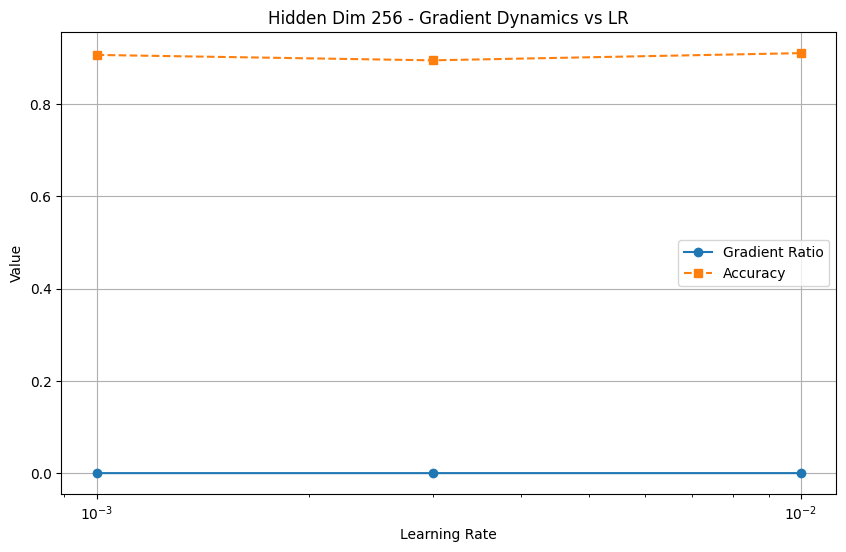


=== Testing h_dim=2048 ===

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: -5.03e-22, σ²: 3.81e-23
  Layer2 - μ: -8.93e-16, σ²: 9.90e-13

Epoch 2:
  Gradient Ratio: 0.00
  Layer1 - μ: -6.35e-21, σ²: 3.44e-23
  Layer2 - μ: 5.03e-17, σ²: 1.47e-15

Epoch 3:
  Gradient Ratio: 0.00
  Layer1 - μ: 7.44e-21, σ²: 3.50e-23
  Layer2 - μ: -1.46e-17, σ²: 2.56e-15

Epoch 4:
  Gradient Ratio: 0.00
  Layer1 - μ: -4.61e-21, σ²: 1.82e-23
  Layer2 - μ: 6.16e-17, σ²: 3.70e-16

Epoch 5:
  Gradient Ratio: 0.00
  Layer1 - μ: -1.30e-21, σ²: 1.96e-23
  Layer2 - μ: -4.60e-17, σ²: 6.79e-16

Epoch 6:
  Gradient Ratio: 0.00
  Layer1 - μ: 9.53e-22, σ²: 1.53e-23
  Layer2 - μ: -2.78e-17, σ²: 4.27e-16

Epoch 7:
  Gradient Ratio: 0.00
  Layer1 - μ: 2.54e-21, σ²: 9.86e-24
  Layer2 - μ: -1.43e-17, σ²: 3.01e-16

Epoch 8:
  Gradient Ratio: 0.00
  Layer1 - μ: -3.19e-21, σ²: 1.24e-23
  Layer2 - μ: 5.69e-18, σ²: 4.48e-16

Epoch 1:
  Gradient Ratio: 0.00
  Layer1 - μ: 4.00e-19, σ²: 5.25e-20
  Layer2 - μ: 7.29e-16, σ²: 2.89e-12

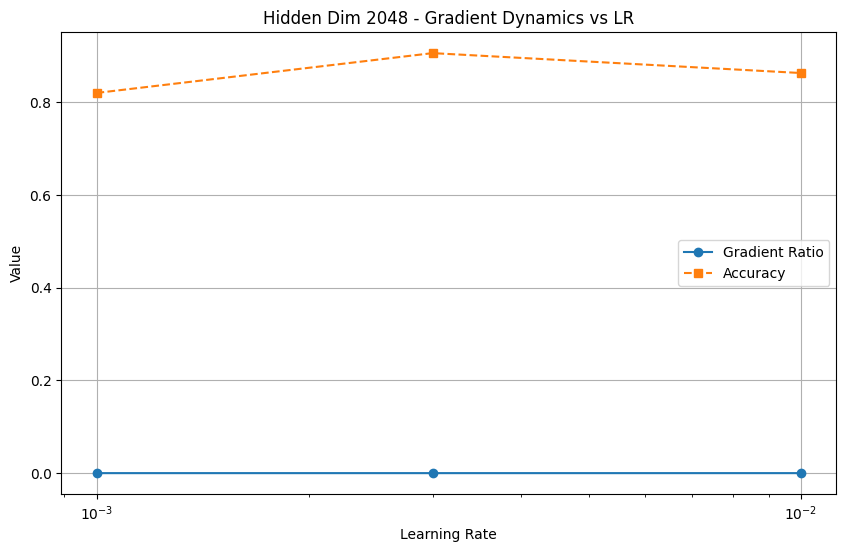

In [65]:
h_dims = [16, 256, 2048]
h_lrs = [1e-3, 3e-3, 1e-2]

for h_dim in h_dims:
    print(f"\n=== Testing h_dim={h_dim} ===")
    dim_metrics = []
    
    for h_lr in h_lrs:
        model, optim_h, optim_w = init(batch_size, h_dim, h_lr)
        acc, metrics = run_with_ratio(nm_epochs, model, optim_h, optim_w, train_dl, test_dl)
        
        # Track final epoch metrics
        final_metrics = metrics[-1]
        final_metrics['acc'] = acc
        dim_metrics.append(final_metrics)
        
    # Plot width-LR relationship
    plt.figure(figsize=(10, 6))
    plt.plot(h_lrs, [m['ratio'] for m in dim_metrics], 'o-', label='Gradient Ratio')
    plt.plot(h_lrs, [m['acc'] for m in dim_metrics], 's--', label='Accuracy')
    plt.xscale('log')
    plt.title(f"Hidden Dim {h_dim} - Gradient Dynamics vs LR")
    plt.xlabel("Learning Rate")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()



=== Testing SILU ===
Running silu with h_dim=16 and h_lr=1e-03 → Accuracy: 89.06%
Running silu with h_dim=16 and h_lr=3e-02 → Accuracy: 96.09%
Running silu with h_dim=32 and h_lr=1e-03 → Accuracy: 89.06%
Running silu with h_dim=32 and h_lr=3e-02 → Accuracy: 96.88%

=== Testing SELU ===
Running selu with h_dim=16 and h_lr=1e-03 → Accuracy: 89.84%
Running selu with h_dim=16 and h_lr=3e-02 → Accuracy: 86.72%
Running selu with h_dim=32 and h_lr=1e-03 → Accuracy: 88.67%
Running selu with h_dim=32 and h_lr=3e-02 → Accuracy: 88.67%


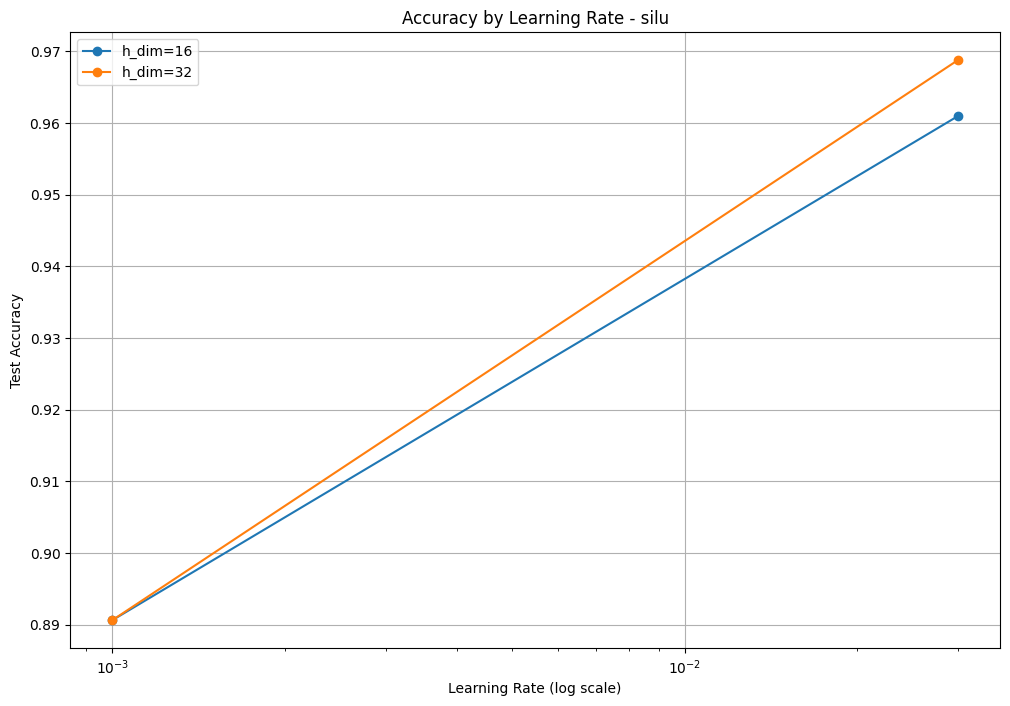

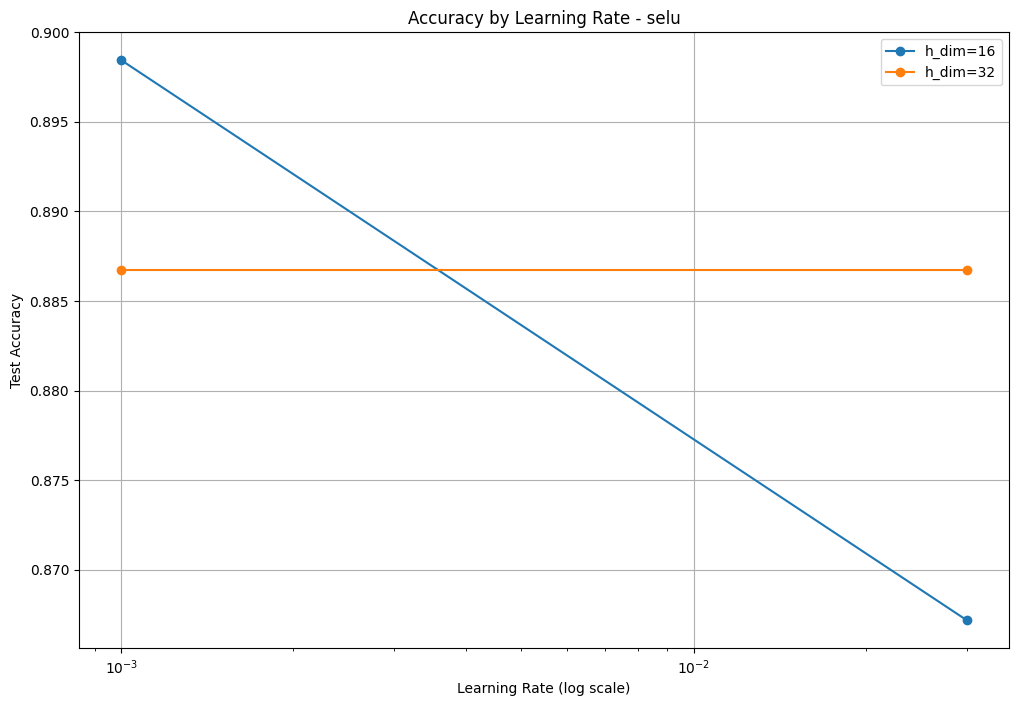

In [61]:

# Add global scale calculation
def calculate_global_scale(acc_results):
    all_means = []
    all_vars = []
    for act_name in acc_results:
        for h_dim in acc_results[act_name]:
            metrics = acc_results[act_name][h_dim]['metrics']
            all_means.extend([m['grad_mean'] for m in metrics])
            all_vars.extend([m['grad_var'] for m in metrics])
    
    mean_min, mean_max = np.nanmin(all_means), np.nanmax(all_means)
    var_min, var_max = np.nanmin(all_vars), np.nanmax(all_vars)
    
    # Add 10% buffer
    return (mean_min*0.9, mean_max*1.1), (var_min*0.9, var_max*1.1)

# Modified plotting function
def plot_grad_stats(metrics, act_name, h_dim, mean_range, var_range):
    plt.figure(figsize=(14, 6))
    
    # Gradient Means
    plt.subplot(1, 2, 1)
    plt.plot(range(len(metrics)), [m['grad_mean'] for m in metrics],
             marker='o', linestyle='-', color='blue')
    plt.ylim(mean_range)
    plt.title(f"Gradient Means - {act_name} (h_dim={h_dim})")
    plt.xlabel("Training Batch")
    plt.ylabel("Mean Gradient Value")
    plt.grid(True)
    
    # Gradient Variances
    plt.subplot(1, 2, 2)
    plt.plot(range(len(metrics)), [m['grad_var'] for m in metrics],
             marker='o', linestyle='-', color='red')
    plt.ylim(var_range)
    plt.title(f"Gradient Variances - {act_name} (h_dim={h_dim})")
    plt.xlabel("Training Batch")
    plt.ylabel("Gradient Variance")
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"gradients_{act_name}_h{h_dim}.png")
    plt.show()  # Display in notebook
    plt.close()


# --- Global Analysis Setup ---
all_metrics = []
acc_results = {}
condition_numbers = {}

# --- Main Experiment Loop ---
# First collect all metrics
for act_name, act_fn in activation_fns:
    print(f"\n=== Testing {act_name.upper()} ===")
    acc_results[act_name] = {}
    condition_numbers[act_name] = {}
    
    for h_dim in h_dims:
        acc_results[act_name][h_dim] = {
            'accs': [],  # Store accuracies here
            'metrics': []  # Store metrics here
        }

        condition_numbers[act_name][h_dim] = []
        
        for h_lr in h_lrs:
            print(f"Running {act_name} with h_dim={h_dim} and h_lr={h_lr:.0e}", end=" ")
            model, optim_h, optim_w = init(batch_size, h_dim, h_lr, act_fn=act_fn)
            a = run(nm_epochs, model, optim_h, optim_w, train_dl, test_dl, 8)
            metrics = train(train_dl, T=8, model=model, optim_w=optim_w, optim_h=optim_h)
            
            # Store results in dictionary
            acc_results[act_name][h_dim]['accs'].append(a)
            acc_results[act_name][h_dim]['metrics'].extend(metrics)

            # Collect condition numbers
            cond_nums = get_condition_numbers(model)
            condition_numbers[act_name][h_dim].append(cond_nums)
            
            print(f"→ Accuracy: {(a*100.0):.2f}%")

# --- Calculate Global Scales ---
def get_global_scale(all_metrics):
    all_means = [m['grad_mean'] for m in all_metrics if m is not None]
    all_vars = [m['grad_var'] for m in all_metrics if m is not None]
    
    mean_min = np.nanmin(all_means) if all_means else 0
    mean_max = np.nanmax(all_means) if all_means else 1
    var_min = np.nanmin(all_vars) if all_vars else 0
    var_max = np.nanmax(all_vars) if all_vars else 1
    
    # Add 10% buffer
    mean_range = (mean_min - 0.1*(mean_max-mean_min), 
                 mean_max + 0.1*(mean_max-mean_min))
    var_range = (var_min - 0.1*(var_max-var_min),
                var_max + 0.1*(var_max-var_min))
    
    return mean_range, var_range

global_mean_range, global_var_range = get_global_scale(all_metrics)

# --- Generate Visualizations ---
for act_name in acc_results:
    for h_dim in acc_results[act_name]:
        metrics = acc_results[act_name][h_dim]['metrics']
        accs = acc_results[act_name][h_dim]
        
        # Plot gradient statistics
        plt.figure(figsize=(14, 6))
        
        # Gradient Means
        plt.subplot(1, 2, 1)
        plt.plot(range(len(metrics)), [m['grad_mean'] for m in metrics],
                marker='o', linestyle='-', color='blue')
        plt.ylim(global_mean_range)
        plt.title(f"Gradient Means - {act_name} (h_dim={h_dim})")
        plt.xlabel("Training Batch")
        plt.ylabel("Mean Gradient Value")
        plt.grid(True)
        
        # Gradient Variances
        plt.subplot(1, 2, 2)
        plt.plot(range(len(metrics)), [m['grad_var'] for m in metrics],
                marker='o', linestyle='-', color='red')
        plt.ylim(global_var_range)
        plt.title(f"Gradient Variances - {act_name} (h_dim={h_dim})")
        plt.xlabel("Training Batch")
        plt.ylabel("Gradient Variance")
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(f"gradients_{act_name}_h{h_dim}.png")
        plt.close()
        
        # Generate text report
        # Corrected report generation
        report = f"""
        Activation: {act_name}
        Hidden Dim: {h_dim}
        Best Accuracy: {max(accs['accs']) * 100:.2f}%  # Convert to percentage manually
        Mean Condition Number: {np.mean(condition_numbers[act_name][h_dim]):.2f}
        Gradient Statistics:
        - Global Mean Range: {global_mean_range[0]:.2e} to {global_mean_range[1]:.2e}
        - Global Var Range: {global_var_range[0]:.2e} to {global_var_range[1]:.2e}
        """

        
        with open(f"report_{act_name}_h{h_dim}.txt", "w") as f:
            f.write(report)

# --- Plot Accuracy Surfaces ---
for act_name in acc_results:
    plt.figure(figsize=(12, 8))
    
    for h_dim in acc_results[act_name]:
        accs = acc_results[act_name][h_dim]['accs']
        plt.plot(h_lrs, accs, marker='o', linestyle='-', 
                label=f'h_dim={h_dim}')
    
    plt.title(f"Accuracy by Learning Rate - {act_name}")
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Test Accuracy")
    plt.xscale('log')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"accuracy_{act_name}.png")
    plt.show()  # Display in notebook
    plt.close()




In [56]:
acc_results

{'silu': {16: {'accs': [np.float32(0.90625), np.float32(0.9375)],
   'metrics': [{'grad_mean': Array(1.0228788e-06, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(1.0642424e-06, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(3.897068e-07, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(1.0048186e-06, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(6.5239885e-07, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(5.9863646e-07, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(7.987287e-07, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(1.616663e-06, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(0.00323965, dtype=float32),
     'grad_var': Array(0., dtype=float32)},
    {'grad_mean': Array(0.0014883, dty

In [ ]:
Ok